# Fashion MNIST Classifier using MLP (Multi Layer Perceptron)

## 1. Loading the dataset

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

In [2]:
train_data = datasets.FashionMNIST(
    root="../data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root="../data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

print(f"Length of train data: {len(train_data)}")
print(f"Length of test data: {len(test_data)}")

Length of train data: 60000
Length of test data: 10000


In [3]:
class_names = train_data.classes
print(class_names)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## 2. Visualizing the dataset images

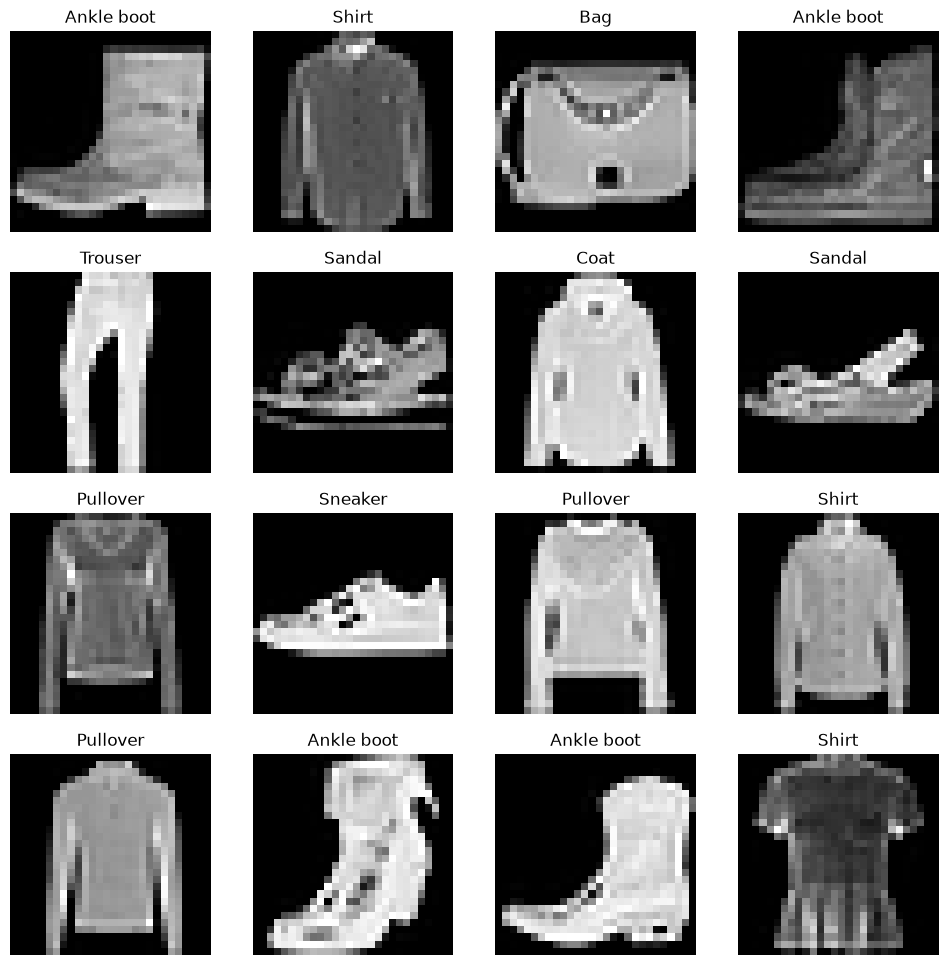

In [4]:
torch.manual_seed(42)
fig = plt.figure(figsize=(12, 12))
rows, cols = 4, 4
for i in range(1, rows*cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i);
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False)

## 3. Setting up Dataloaders and Device-Agnostic Code

In [5]:
BATCH_SIZE = 32

train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Length of train_dataloader: {len(train_dataloader)}, No. of images per batch: {BATCH_SIZE}")
print(f"Length of test_dataloader: {len(test_dataloader)}, No. of images per batch: {BATCH_SIZE}")

Length of train_dataloader: 1875, No. of images per batch: 32
Length of test_dataloader: 313, No. of images per batch: 32


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")

Device : cuda


## 4. Defining the model

In [7]:
class MNISTModel0(nn.Module):
    def __init__(self, input_features: int, output_features: int):

        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_features, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_features)
        )

    def forward(self, x):
        return self.network(x)

model_0 = MNISTModel0(
    input_features=784,
    output_features=len(class_names)
).to(device)

model_0

MNISTModel0(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=10, bias=True)
  )
)

## 5. Setting up loss function, optimizer and classification metrics

In [8]:
from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassPrecision,
    MulticlassRecall,
    MulticlassF1Score
)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=model_0.parameters(),
    lr=0.001
)

train_accuracy = MulticlassAccuracy(
    num_classes=len(class_names),
    average="weighted"
).to(device)

train_precision = MulticlassPrecision(
    num_classes=len(class_names),
    average="weighted"
).to(device)

train_recall = MulticlassRecall(
    num_classes=len(class_names),
    average="weighted"
).to(device)

train_f1 = MulticlassF1Score(
    num_classes=len(class_names),
    average="weighted"
).to(device)


test_accuracy = MulticlassAccuracy(
    num_classes=len(class_names),
    average="weighted"
).to(device)

test_precision = MulticlassPrecision(
    num_classes=len(class_names),
    average="weighted"
).to(device)

test_recall = MulticlassRecall(
    num_classes=len(class_names),
    average="weighted"
).to(device)

test_f1 = MulticlassF1Score(
    num_classes=len(class_names),
    average="weighted"
).to(device)

## 6. Training and Inference Loop

In [9]:
epochs = 20

train_loss_history, test_loss_history = [], []
train_acc_history, test_acc_history = [], []
train_precision_history, test_precision_history = [], []
train_recall_history, test_recall_history = [], []
train_f1_history, test_f1_history = [], []

for epoch in range(epochs):
    print(f"Epoch {epoch}: \n----------")

    train_loss = 0

    for batch, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)
        model_0.train()

        y_pred = model_0(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        train_accuracy.update(y_pred, y)
        train_precision.update(y_pred, y)
        train_recall.update(y_pred, y)
        train_f1.update(y_pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)} / {len(train_dataloader.dataset)} samples")

    train_loss /= len(train_dataloader)

    train_acc = train_accuracy.compute()
    train_prec = train_precision.compute()
    train_rec = train_recall.compute()
    train_f1_score = train_f1.compute()

    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc.item())
    train_precision_history.append(train_prec.item())
    train_recall_history.append(train_rec.item())
    train_f1_history.append(train_f1_score.item())

    train_accuracy.reset()
    train_precision.reset()
    train_recall.reset()
    train_f1.reset()

    test_loss = 0
    model_0.eval()
    with torch.inference_mode():
        for X_test, y_test in test_dataloader:
            X_test, y_test = X_test.to(device), y_test.to(device)
            test_pred = model_0(X_test)
            test_loss += loss_fn(test_pred, y_test).item()

            test_accuracy.update(test_pred, y_test)
            test_precision.update(test_pred, y_test)
            test_recall.update(test_pred, y_test)
            test_f1.update(test_pred, y_test)

        test_loss /= len(test_dataloader)

        test_acc = test_accuracy.compute()
        test_prec = test_precision.compute()
        test_rec = test_recall.compute()
        test_f1_score = test_f1.compute()

        test_loss_history.append(test_loss)
        test_acc_history.append(test_acc.item())
        test_precision_history.append(test_prec.item())
        test_recall_history.append(test_rec.item())
        test_f1_history.append(test_f1_score.item())

        # Reset testing metrics
        test_accuracy.reset()
        test_precision.reset()
        test_recall.reset()
        test_f1.reset()

    print(
        f"\nTrain Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Train Precision: {train_prec:.4f} | "
        f"Train Recall: {train_rec:.4f} | "
        f"Train F1: {train_f1_score:.4f}"
    )

    print(
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f} | "
        f"Test Precision: {test_prec:.4f} | "
        f"Test Recall: {test_rec:.4f} | "
        f"Test F1: {test_f1_score:.4f}\n"
    )


Epoch 0: 
----------
Looked at 0 / 60000 samples
Looked at 12800 / 60000 samples
Looked at 25600 / 60000 samples
Looked at 38400 / 60000 samples
Looked at 51200 / 60000 samples

Train Loss: 0.5629 | Train Acc: 0.8008 | Train Precision: 0.7992 | Train Recall: 0.8008 | Train F1: 0.7989
Test Loss: 0.4483 | Test Acc: 0.8408 | Test Precision: 0.8404 | Test Recall: 0.8408 | Test F1: 0.8388

Epoch 1: 
----------
Looked at 0 / 60000 samples
Looked at 12800 / 60000 samples
Looked at 25600 / 60000 samples
Looked at 38400 / 60000 samples
Looked at 51200 / 60000 samples

Train Loss: 0.4037 | Train Acc: 0.8551 | Train Precision: 0.8542 | Train Recall: 0.8551 | Train F1: 0.8543
Test Loss: 0.4342 | Test Acc: 0.8403 | Test Precision: 0.8491 | Test Recall: 0.8403 | Test F1: 0.8385

Epoch 2: 
----------
Looked at 0 / 60000 samples
Looked at 12800 / 60000 samples
Looked at 25600 / 60000 samples
Looked at 38400 / 60000 samples
Looked at 51200 / 60000 samples

Train Loss: 0.3620 | Train Acc: 0.8691 | Train

## 7. Plotting Loss and Accuracy curves

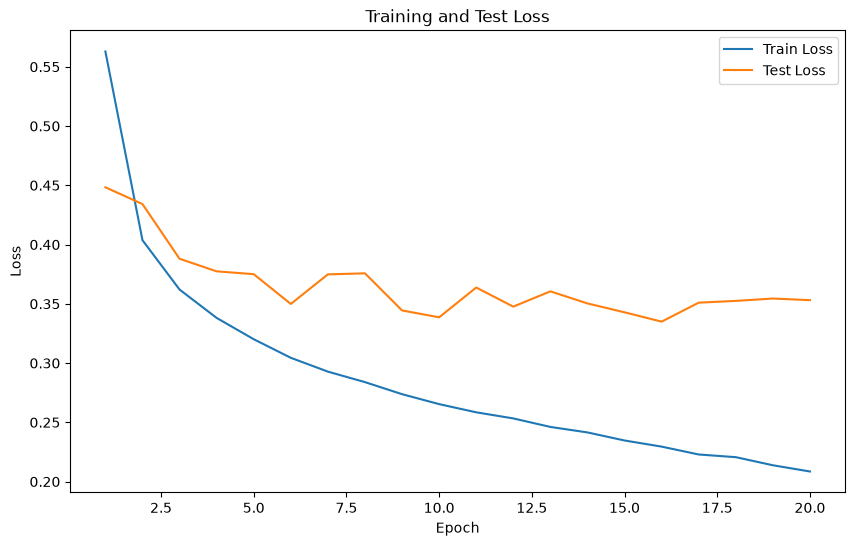

In [20]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    train_loss_history,
    label="Train Loss"
)

plt.plot(
    epochs_range,
    test_loss_history,
    label="Test Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()

plt.show()

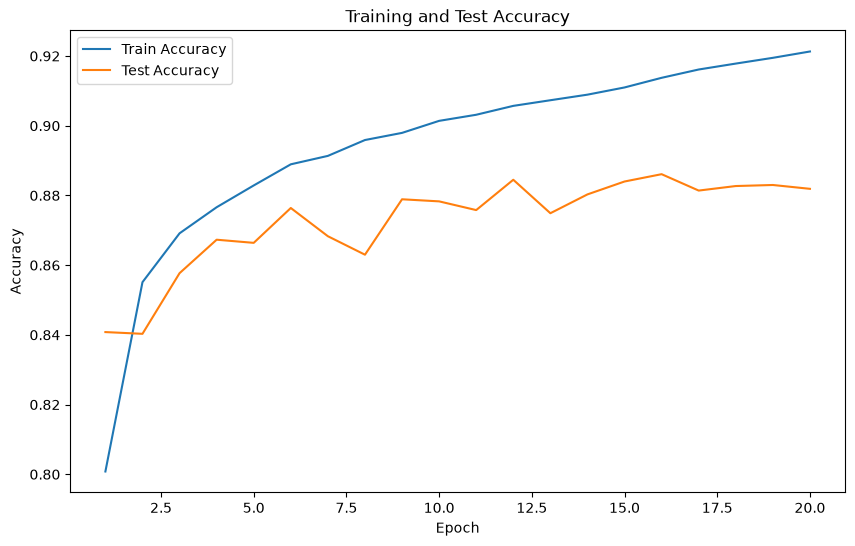

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    train_acc_history,
    label="Train Accuracy"
)

plt.plot(
    epochs_range,
    test_acc_history,
    label="Test Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")
plt.legend()

plt.show()

## 8. Saving the baseline model

In [23]:
torch.save(model_0.state_dict(), r"../models/baseline.pt")
print(f"Baseline Model saved to models/baseline.pt")

Baseline Model saved to models/baseline.pt
